In [11]:
import uproot
import matplotlib.pyplot as plt
plt.style.use("/Users/rvizarreta/Library/CloudStorage/GoogleDrive-rvizarreta14@gmail.com/My Drive/🏛 PhD Repository/🚀 Research/🤖 Experiments&Projects/ICARUS/ICARUS_CC0pi_GUNDAM/gundam-icarus/style.mplstyle")
import numpy as np

In [12]:
def plot_cross_section(filename, hist_path, xlabel, ylabel, bin_edges_labels,
                       title_line1=None,
                       figsize=(5, 4), output_name=None, pot='POT'):
    """
    Plot cross-section data from a ROOT file with error bars.

    Parameters
    ----------
    filename : str
        Path to the ROOT file
    hist_path : str
        Path to the histogram within the ROOT file (e.g., "gundam/calcXsec/throws/histograms/TrueDeltaPT_XS_TH1D;1")
    xlabel : str
        Label for the x-axis (use raw string with LaTeX, e.g., r'True $\delta_{pT}$ [GeV]')
    ylabel : str
        Label for the y-axis (use raw string with LaTeX, e.g., r'$\frac{d\sigma}{dp_T}$ $\left[\frac{cm^2}{GeV/c^2}\right]$')
    bin_edges_labels : list
        List of bin edge values to display on x-axis (e.g., [0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
    title_line1 : str, optional
        First line of title (e.g., "ICARUS · NuMI Data (10% Run 2)")
    figsize : tuple, optional
        Figure size (width, height). Default is (5, 4)
    output_name : str, optional
        Output filename for saving the plot. If None, uses the histogram name. Default is None

    Returns
    -------
    fig, ax : matplotlib figure and axis objects
    """
    # Open the ROOT file
    file = uproot.open(filename)

    # Navigate to the histogram
    hist = file[hist_path]

    # Extract bin values and errors
    bin_values = hist.values()*1e40
    bin_errors = hist.errors()*1e40

    # Calculate bin centers from provided bin edges
    bin_edges_array = np.array(bin_edges_labels)
    bin_centers = (bin_edges_array[:-1] + bin_edges_array[1:]) / 2
    bin_widths = np.diff(bin_edges_array)

    # Create the plot
    fig, ax = plt.subplots(figsize=figsize)

    # Plot using errorbar
    ax.errorbar(bin_centers,
                bin_values,
                xerr=bin_widths / 2,  # Half bin width for symmetric error bars
                yerr=bin_errors,
                fmt='o',
                markersize=7,
                markerfacecolor='black',
                markeredgecolor='black',
                color='black',
                capsize=4,
                capthick=1.5,
                elinewidth=1.5,
                linewidth=2)

    # Set axis labels
    ax.set_xlabel(xlabel, fontsize=12, weight='bold')
    ax.set_ylabel(ylabel, fontsize=12, weight='bold')

    # Set axis limits
    ax.set_xlim(bin_edges_array[0], bin_edges_array[-1])
    y_min = 0
    y_max = np.max(bin_values + bin_errors) * 1.2
    ax.set_ylim(y_min, y_max)

    # Set x-axis ticks at bin edges
    #ax.set_xticks(bin_edges_array)
    #ax.set_xticklabels([f'{x:.1f}' for x in bin_edges_array], fontsize=10)

    # Set tick parameters
    ax.tick_params(axis='both', which='major',
                   labelsize=12,
                   size=8,
                   width=2,
                   direction='in')

    # Enable minor ticks
    ax.minorticks_on()
    ax.tick_params(axis='y', which='minor',
                   size=4,
                   width=1,
                   direction='in')
    ax.tick_params(axis='x', which='minor',
                   size=4,
                   width=1,
                   direction='in')

    # Add two-line title if provided (RIGHT-aligned)
    if title_line1:
        title_text = ""
        if title_line1:
            title_text += title_line1

        yrange = ax.get_ylim()
        usey = yrange[1] + 0.01*(yrange[1] - yrange[0]) + 0.0*(yrange[1] - yrange[0])
        xrange = ax.get_xlim()
        usex = xrange[0] + 0.01*(xrange[1] - xrange[0]) + 0.0*(xrange[1] - xrange[0])
        color = 'chocolate' if 'data' in title_line1.lower() else 'blue'
        ax.text(x=usex, y=usey, s=title_line1, fontsize=10, color=color, verticalalignment='bottom')
        usex_right = xrange[1] - 0.025*(xrange[1] - xrange[0])
        ax.text(x=usex_right, y=usey, s=pot, fontsize=10, color="black",
                verticalalignment='bottom', horizontalalignment='right')

    # Force font family on tick labels after formatting
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontfamily('sans-serif')

    # Also set font for the offset text (scientific notation exponent)
    ax.yaxis.get_offset_text().set_fontfamily('sans-serif')
    ax.xaxis.get_offset_text().set_fontfamily('sans-serif')

    # Grid
    ax.grid(True, alpha=0.3)

    # Save the plot
    if output_name is None:
        output_name = f"{hist.name}_matplotlib.png"
    plt.savefig(output_name, dpi=300, bbox_inches='tight')

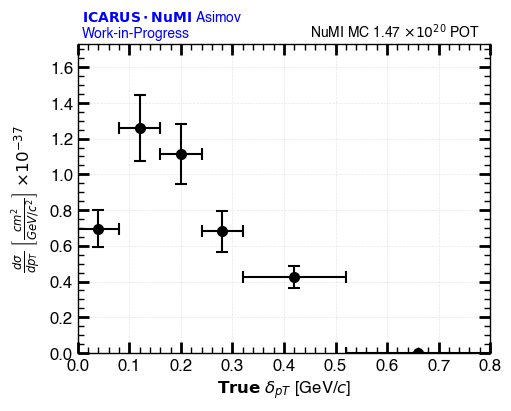

In [13]:
plot_cross_section(
        filename='/Users/rvizarreta/Library/CloudStorage/GoogleDrive-rvizarreta14@gmail.com/My Drive/🏛 PhD Repository/🚀 Research/🤖 Experiments&Projects/ICARUS/ICARUS_CC0pi_GUNDAM/data/exampleXSec.root',
        hist_path="calcXsec/histograms/TrueDeltaPT_XS_TH1D;1",
        xlabel=r'$\mathbf{True}$ $\delta_{pT}$ [GeV/$c$]',
        ylabel=r'$\frac{d\sigma}{dp_T}$ $\left[\frac{cm^2}{GeV/c^2}\right]$ $\times 10^{-37}$',
        bin_edges_labels=[0.0, 0.08, 0.16, 0.24, 0.32, 0.52, 0.8],
        title_line1=r'$\bf{ICARUS \cdot NuMI}$ Asimov' + '\n' + 'Work-in-Progress',
        output_name='TrueDeltaPT_XS_matplotlib.png',
        pot=r'NuMI MC 1.47 $\times 10^{20}$ POT'
)

### Bin by bin calculation

In [8]:
import uproot
import awkward as ak
import numpy as np

# Open the ROOT file
file_path = "/Users/rvizarreta/Library/CloudStorage/GoogleDrive-rvizarreta14@gmail.com/My Drive/🏛 PhD Repository/🚀 Research/🤖 Experiments&Projects/ICARUS/ICARUS_CC0pi_Selection/data/icarus_numi_numu_mc_onbeam_offbeam_syst_gundam.root"

print("Opening file...")
file = uproot.open(file_path)

# List available trees to find the signal tree
print("\nAvailable keys in file:")
print(file.keys())

# Try to get the signal tree
try:
    tree = file["events/full/signal"]
    print(f"\nFound tree: events/full/signal")
    print(f"Number of entries: {tree.num_entries}")

    # Read the branches we need
    print("\nReading branches...")
    arrays = tree.arrays(["true_dpT", "category"], library="ak")

    print(f"Total events in tree: {len(arrays)}")

    # Apply signal selection: category = 0, 1, 3, or 4
    signal_mask = (arrays.category == 0) | (arrays.category == 1) | (arrays.category == 3) | (arrays.category == 4)
    signal_events = arrays[signal_mask]

    print(f"Events passing signal selection: {len(signal_events)}")

    # Define true dpT bins (in MeV/c)
    bins = [(0, 80), (80, 160), (160, 240), (240, 320), (320, 520), (520, 99999)]

    print("\n" + "="*60)
    print("Signal Events per True δpT Bin")
    print("="*60)
    print(f"{'Bin Range (MeV/c)':<25} {'N_Signal':<15} {'Bin Width (MeV)'}")
    print("-"*60)

    total_signal = 0
    for bin_low, bin_high in bins:
        # Count events in this bin
        bin_mask = (signal_events.true_dpT >= bin_low) & (signal_events.true_dpT < bin_high)
        n_signal = ak.sum(bin_mask)

        bin_width = bin_high - bin_low if bin_high < 99999 else "∞"

        print(f"{bin_low:>6.0f} - {bin_high:<6.0f} MeV/c    {n_signal:<15} {bin_width}")
        total_signal += n_signal

    print("-"*60)
    print(f"{'Total':<25} {total_signal}")
    print("="*60)

    # Some basic statistics
    print("\nTrue δpT Statistics for Signal Events:")
    print(f"  Mean: {ak.mean(signal_events.true_dpT):.2f} MeV/c")
    print(f"  Std:  {ak.std(signal_events.true_dpT):.2f} MeV/c")
    print(f"  Min:  {ak.min(signal_events.true_dpT):.2f} MeV/c")
    print(f"  Max:  {ak.max(signal_events.true_dpT):.2f} MeV/c")

except Exception as e:
    print(f"\nError: {e}")
    print("\nTrying to find the correct tree path...")
    print("Available paths:")
    for key in file.keys():
        print(f"  - {key}")

Opening file...

Available keys in file:
['events;1', 'events/full;1', 'events/full/POT;3', 'events/full/POT;2', 'events/full/POT;1', 'events/full/Livetime;3', 'events/full/Livetime;2', 'events/full/Livetime;1', 'events/full/selected;1', 'events/full/sideband;1', 'events/full/signal;1', 'selected_multisimTree;22', 'selected_multisimTree;21']

Found tree: events/full/signal
Number of entries: 24109

Reading branches...
Total events in tree: 24109
Events passing signal selection: 24109

Signal Events per True δpT Bin
Bin Range (MeV/c)         N_Signal        Bin Width (MeV)
------------------------------------------------------------
     0 - 80     MeV/c    2943            80
    80 - 160    MeV/c    5342            80
   160 - 240    MeV/c    4718            80
   240 - 320    MeV/c    2894            80
   320 - 520    MeV/c    4491            200
   520 - 99999  MeV/c    3721            ∞
------------------------------------------------------------
Total                     24109

Tr

In [6]:
flux = 1.142e11
N_target = 4.714e30
denominator = flux * N_target
print(denominator)

5.3833880000000004e+41


In [5]:
# Bin 1:
delta_x = 80
N_signal = 2943
x_sec = N_signal/(delta_x*denominator)
print(x_sec)

6.833521938229234e-41


In [7]:
# Bin 2:
delta_x = 80
N_signal = 5342
x_sec = N_signal/(delta_x*denominator)
print(x_sec)

1.2403898808705594e-40
